In [ ]:
%load_ext autoreload
%autoreload 2

# Otimização Optuna

## Inicialização dos datasets

In [ ]:
from src.Anomaly.Optimizer import AnomalyOptunaOptimizer
from src.Data.Processor import DataStreamProcessor
import pandas as pd
from datetime import datetime

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']

datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

FEATURES = [
    'Max Packet Length',
    'Average Packet Size',
    'Fwd Packet Length Min',
    'Min Packet Length',
    'Fwd Packet Length Max',
    'Packet Length Mean',
    'Fwd Packet Length Mean',
    'Avg Fwd Segment Size',
    'min_seg_size_forward',
    'ACK Flag Count',
    'Flow Duration',
    'Fwd IAT Total',
    'Flow IAT Max',
    'Fwd IAT Max',
    'Flow IAT Std',
    'Fwd IAT Std',
    'Fwd IAT Mean',
    'Flow IAT Mean',
    'Total Length of Fwd Packets',
    'Subflow Fwd Bytes',
    'act_data_pkt_fwd',
    'Subflow Fwd Packets',
    'Total Fwd Packets',
    'Down/Up Ratio',
    'Init_Win_bytes_backward',
    'Total Length of Bwd Packets',
    'Subflow Bwd Bytes',
    'Flow IAT Min',
    'Bwd Packet Length Max',
    'URG Flag Count',
    'Bwd IAT Total',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
]

## Todas as características

In [ ]:
id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando otimização para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    optimizer = AnomalyOptunaOptimizer(
        stream=stream,
        n_trials=100,
        discretization_threshold='dinamic',
        target_names=targets,
        n_runs=5
    )
    
    best_params = optimizer.optimize(
        model_name='AIF',           # HST, AIF, AE, OIF
        warmup_instances=0,
        experiment_name=nome_experimento,
        num_features=len(features),
        exec_id=id_execucao,
        window_evaluation=100
    )

## Melhores características

In [ ]:
%load_ext autoreload
%autoreload 2

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando otimização para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=FEATURES)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    optimizer = AnomalyOptunaOptimizer(
        stream=stream,
        n_trials=5,
        discretization_threshold='dinamic',
        target_names=targets,
        n_runs=5
    )
    
    best_params = optimizer.optimize(
        model_name='HST',           # HST, AIF, AE, OIF
        warmup_instances=0,
        experiment_name=nome_experimento,
        num_features=len(features),
        exec_id=id_execucao,
        window_evaluation=100
    )

# Execução Default

## Inicialização dos Datasets

In [8]:
from src.Anomaly.Pipeline import AnomalyExperimentRunner
from src.Anomaly.Models import get_anomaly_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']

# categorias = ['Generalização', 'Adaptação']
# tamanhos = ['200']

datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

FEATURES = [
    'Max Packet Length',
    'Average Packet Size',
    'Fwd Packet Length Min',
    'Min Packet Length',
    'Fwd Packet Length Max',
    'Packet Length Mean',
    'Fwd Packet Length Mean',
    'Avg Fwd Segment Size',
    'min_seg_size_forward',
    'ACK Flag Count',
    'Flow Duration',
    'Fwd IAT Total',
    'Flow IAT Max',
    'Fwd IAT Max',
    'Flow IAT Std',
    'Fwd IAT Std',
    'Fwd IAT Mean',
    'Flow IAT Mean',
    'Total Length of Fwd Packets',
    'Subflow Fwd Bytes',
    'act_data_pkt_fwd',
    'Subflow Fwd Packets',
    'Total Fwd Packets',
    'Down/Up Ratio',
    'Init_Win_bytes_backward',
    'Total Length of Bwd Packets',
    'Subflow Bwd Bytes',
    'Flow IAT Min',
    'Bwd Packet Length Max',
    'URG Flag Count',
    'Bwd IAT Total',
    'Bwd Packets/s',
    'Init_Win_bytes_forward',
]

## Adaptative Isolation Forest (AIF)

### Todas as características

In [9]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_aif = {
    'window_size': 256,
    'n_trees': 100,
    'height': None,
    'm_trees': 10,
    'weights': 0.5
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AIF'],
        aif_params=default_aif
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.50,
        algorithm_params=default_aif,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando treinamento para: Consistência_25

[AdaptiveIsolationForest] Executando 5 rodada(s) prequencial(is)...

                                                                                          METRICS REPORT | DEFAULT_FULLFEATURES                                                                                           
Algorithm              | F1 (%)            | Prec (%)          | Rec (%)           | MCC               | FP          | FN          | Time (s)        | Discrtz    | Win_Eval   | window_size | n_trees | m_trees | weights
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AdaptiveIsolationForest |  5.8210 ± 0.0477 |  3.0494 ± 0.0262 | 63.8889 ± 0.0000 |  0.1244 ± 0.0007 | 1463 |   26 | 0.7231 | 0.5000     | 10

### Melhores Características

In [10]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_aif = {
    'window_size': 256,
    'n_trees': 100,
    'height': None,
    'm_trees': 10,
    'weights': 0.5
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=FEATURES)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AIF'],
        aif_params=default_aif
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.50,
        algorithm_params=default_aif,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando treinamento para: Consistência_25

[AdaptiveIsolationForest] Executando 5 rodada(s) prequencial(is)...

                                                                                           METRICS REPORT | DEFAULT_33FEATURES                                                                                            
Algorithm              | F1 (%)            | Prec (%)          | Rec (%)           | MCC               | FP          | FN          | Time (s)        | Discrtz    | Win_Eval   | window_size | n_trees | m_trees | weights
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
AdaptiveIsolationForest |  9.0625 ± 0.0758 |  4.7596 ± 0.0419 | 94.4444 ± 0.0000 |  0.2010 ± 0.0010 | 1361 |    4 | 1.7029 | 0.5000     | 10

## Half Space Trees (HST)

### Todas as Características

In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_hst = {
    'window_size': 250,
    'number_of_trees': 25,
    'max_depth': 15,
    'anomaly_threshold': 0.50,
    'size_limit': 0.10
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['HST'],
        hst_params=default_hst
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.50,
        algorithm_params=default_hst,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

### Melhores características

In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_hst = {
    'window_size': 250,
    'number_of_trees': 25,
    'max_depth': 15,
    'anomaly_threshold': 0.50,
    'size_limit': 0.10
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=FEATURES)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['HST'],
        hst_params=default_hst
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.50,
        algorithm_params=default_hst,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

## Autoencoder (AE)

### Todas as características

In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_ae = {
    'hidden_layer': 2,
    'learning_rate': 0.5,
    'threshold': 0.60
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AE'],
        ae_params=default_ae
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.60,
        algorithm_params=default_ae,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

### Melhores características

In [ ]:
%load_ext autoreload
%autoreload 2

from datetime import datetime

default_ae = {
    'hidden_layer': 2,
    'learning_rate': 0.5,
    'threshold': 0.60
}

id_execucao = datetime.now().strftime("%Y%m%d_%H%M")

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=FEATURES)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_anomaly_models(
        stream.get_schema(),
        selected_models=['AE'],
        ae_params=default_ae
    )
    
    runner = AnomalyExperimentRunner(target_names=targets, n_runs=5)
    
    runner.run_anomaly_evaluation(
        stream,
        algorithms=algoritmos,
        window_evaluation=100,
        warmup_instances=0,
        title=nome_experimento,
        discretization=0.60,
        algorithm_params=default_ae,          
        is_optimized=False,                       
        num_features=len(features),
        exec_id=id_execucao
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


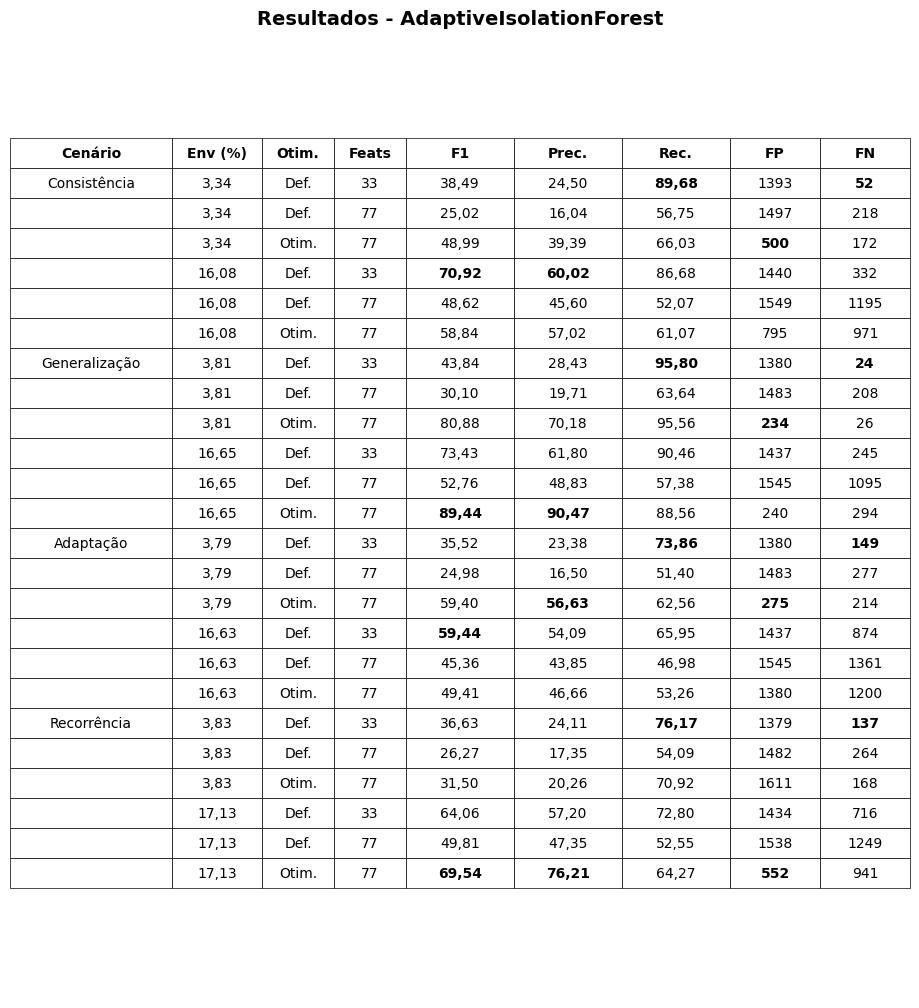


CÓDIGO LATEX PARA OVERLEAF:
\begin{table}[ht]
\centering
\begin{tabular}{|l|c|c|c|c|c|c|c|c|}
\hline
\textbf{Cenário} & \textbf{Env (\%)} & \textbf{Otim.} & \textbf{Feats} & \textbf{F1} & \textbf{Prec.} & \textbf{Rec.} & \textbf{FP} & \textbf{FN} \\ \hline
Consistência & 3,34 & Def. & 33 & 38,49 & 24,50 & \textbf{89,68} & 1393 & \textbf{52} \\
 & 3,34 & Def. & 77 & 25,02 & 16,04 & 56,75 & 1497 & 218 \\
 & 3,34 & Otim. & 77 & 48,99 & 39,39 & 66,03 & \textbf{500} & 172 \\
 & 16,08 & Def. & 33 & \textbf{70,92} & \textbf{60,02} & 86,68 & 1440 & 332 \\
 & 16,08 & Def. & 77 & 48,62 & 45,60 & 52,07 & 1549 & 1195 \\
 & 16,08 & Otim. & 77 & 58,84 & 57,02 & 61,07 & 795 & 971 \\
\hline
Generalização & 3,81 & Def. & 33 & 43,84 & 28,43 & \textbf{95,80} & 1380 & \textbf{24} \\
 & 3,81 & Def. & 77 & 30,10 & 19,71 & 63,64 & 1483 & 208 \\
 & 3,81 & Otim. & 77 & 80,88 & 70,18 & 95,56 & \textbf{234} & 26 \\
 & 16,65 & Def. & 33 & 73,43 & 61,80 & 90,46 & 1437 & 245 \\
 & 16,65 & Def. & 77 & 52,76 & 48,83

In [21]:
%load_ext autoreload
%autoreload 2

from src.Results.Plots import Plots

# Especifique os caminhos dos 4 arquivos CSV do algoritmo que deseja resumir
csvs_aif = {
    "output/AdaptiveIsolationForest/AdaptiveIsolationForest_Otimizado_FullFeatures.csv": "20260416_1737",
    "output/AdaptiveIsolationForest/AdaptiveIsolationForest_Default_FullFeatures.csv": "20260416_1901",
    "output/AdaptiveIsolationForest/AdaptiveIsolationForest_Default_33Features.csv": "20260416_1902",
}

# Inicializamos a classe Plots (o target names aqui é só um placeholder pro init)
plots = Plots(target_names=['Normal', 'Ataque'])

# Geramos a tabela!
plots.plot_summary_table(
    csv_dict=csvs_aif, 
    algo_name="AdaptiveIsolationForest",
    exclude_blocks=['25'],
    include_blocks=['200', '1000']
)